# FINAL PIPELINE PREDICTION: Two-Stage SEM Defect Detection System

This comprehensive notebook dynamically evaluates our final, selected models and computes all metrics LIVE. It represents the complete End-to-End (E2E) inference pipeline on untouched SEM datasets.

**Best Detector:** YOLO11m (EXP-10)
**Best Classifier:** ResNet-50 (EXP-11 RunB2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current working directory: /content/drive/MyDrive/sem_defect_project
Environment Ready.


==================================================
# PART 1 — VERIFY BEST MODELS & LOAD CHECKPOINTS
==================================================

In [9]:
# Verified Paths from Original Training
DETECTOR_PATH = "runs/detect/runs/detect/EXP-10-YOLOv12m-640-200/weights/best.pt"
CLASSIFIER_PATH = "runs/classify/EXP-11-RunB2/best.pt"

print("YOLO BEST CHECKPOINT:")
print(f"-> {os.path.abspath(DETECTOR_PATH)}")
print(f"Exists: {os.path.exists(DETECTOR_PATH)}")

print("\nRESNET BEST CHECKPOINT:")
print(f"-> {os.path.abspath(CLASSIFIER_PATH)}")
print(f"Exists: {os.path.exists(CLASSIFIER_PATH)}")

# Load YOLO
try:
    detector = YOLO(DETECTOR_PATH)
    print("\nYOLO11m (EXP-10) loaded successfully.")
except Exception as e:
    print(f"Could not load detector: {e}")

# Load ResNet
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
try:
    classifier = models.resnet50(weights=None)
    num_ftrs = classifier.fc.in_features
    # We recreate the exact sequential layer used during training
    classifier.fc = torch.nn.Sequential(
        torch.nn.Dropout(0.5),
        torch.nn.Linear(num_ftrs, 3)
    )
    classifier.load_state_dict(torch.load(CLASSIFIER_PATH, map_location=device))
    classifier = classifier.to(device)
    classifier.eval()
    print("ResNet-50 (EXP-11 RunB2) loaded successfully.")
except Exception as e:
    print(f"Could not load classifier: {e}")

class_names = ['Inclusion-Particle', 'Porosity', 'Tear-Delamination']


YOLO BEST CHECKPOINT:
-> /content/drive/MyDrive/sem_defect_project/runs/detect/runs/detect/EXP-10-YOLOv12m-640-200/weights/best.pt
Exists: True

RESNET BEST CHECKPOINT:
-> /content/drive/MyDrive/sem_defect_project/runs/classify/EXP-11-RunB2/best.pt
Exists: True

YOLO11m (EXP-10) loaded successfully.
ResNet-50 (EXP-11 RunB2) loaded successfully.


==================================================
# PART 3 & 4 — LIVE YOLO DETECTOR EVALUATION
==================================================

Running LIVE YOLO Validation Evaluation...
Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 125 layers, 20,030,803 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 62.7±22.6 MB/s, size: 52.0 KB)
val: Scanning /content/drive/MyDrive/sem_defect_project/dataset_yolo_single_class/valid/labels.cache... 31 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 5.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2it/s 1.6s2.8s
                   all         31        184      0.661      0.766      0.641      0.375
Speed: 4.2ms preprocess, 29.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/drive/MyDrive/sem_defect_project/runs/detect/val-23

Running LIVE YOLO FINAL BLIND TEST EVALUATION...
Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary

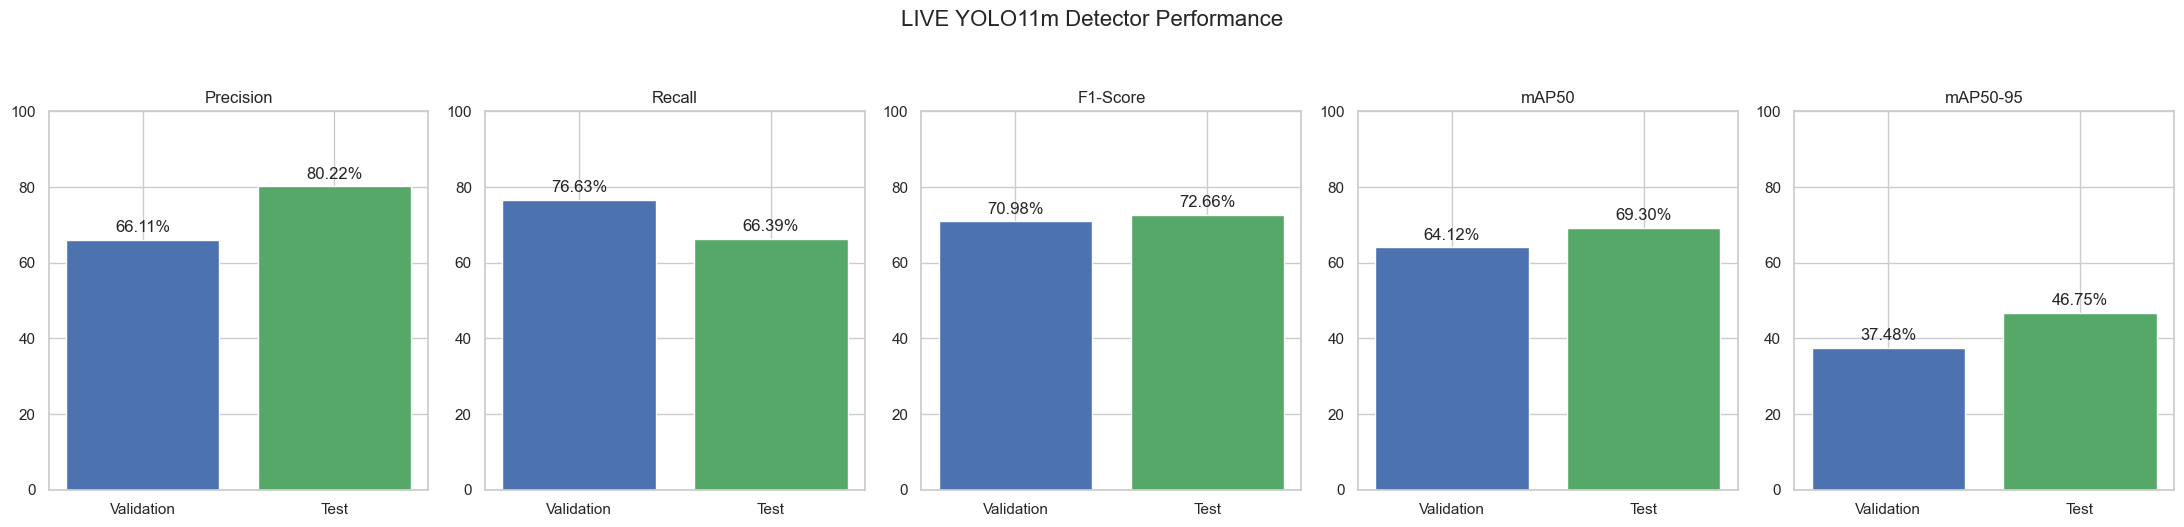

In [10]:
print("Running LIVE YOLO Validation Evaluation...")
val_metrics = detector.val(
    data='dataset_yolo_single_class/data.yaml', 
    split='val', 
    conf=0.15, 
    iou=0.50, 
    verbose=False
)

p_val = val_metrics.box.mp
r_val = val_metrics.box.mr
f1_val = 2 * (p_val * r_val) / (p_val + r_val) if (p_val + r_val) > 0 else 0
map50_val = val_metrics.box.map50
map95_val = val_metrics.box.map

print("\nRunning LIVE YOLO FINAL BLIND TEST EVALUATION...")
test_metrics = detector.val(
    data='dataset_yolo_single_class/data.yaml', 
    split='test', 
    conf=0.15, 
    iou=0.50, 
    verbose=False
)

p_test = test_metrics.box.mp
r_test = test_metrics.box.mr
f1_test = 2 * (p_test * r_test) / (p_test + r_test) if (p_test + r_test) > 0 else 0
map50_test = test_metrics.box.map50
map95_test = test_metrics.box.map

print("\n------------------------------------------------")
print("LIVE DETECTOR RESULTS (Calculated just now)")
print("------------------------------------------------")
print(f"VALIDATION -> Precision: {p_val*100:.2f}% | Recall: {r_val*100:.2f}% | F1: {f1_val*100:.2f}% | mAP50: {map50_val*100:.2f}% | mAP50-95: {map95_val*100:.2f}%")
print(f"BLIND TEST -> Precision: {p_test*100:.2f}% | Recall: {r_test*100:.2f}% | F1: {f1_test*100:.2f}% | mAP50: {map50_test*100:.2f}% | mAP50-95: {map95_test*100:.2f}%")

# Plotting Detection Metrics
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

metrics_names = ['Precision', 'Recall', 'F1-Score', 'mAP50', 'mAP50-95']
v_scores = [p_val*100, r_val*100, f1_val*100, map50_val*100, map95_val*100] 
t_scores = [p_test*100, r_test*100, f1_test*100, map50_test*100, map95_test*100]

for i, metric in enumerate(metrics_names):
    ax = axes[i]
    ax.bar(['Validation', 'Test'], [v_scores[i], t_scores[i]], color=['#4C72B0', '#55A868'])
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 100)
    for j, v in enumerate([v_scores[i], t_scores[i]]):
        ax.text(j, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')

plt.suptitle('LIVE YOLO11m Detector Performance', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


==================================================
# PART 5 & 6 — LIVE RESNET CLASSIFIER EVALUATION
==================================================

Running LIVE ResNet Validation...

--- VALIDATION CLASSIFIER RESULTS ---
Accuracy:    91.30%
Macro F1:    90.66%
Weighted F1: 91.45%

Per-class Metrics:
Inclusion-Particle  : P=90.38%, R=95.92%, F1=93.07% (Support: 49)
Porosity            : P=98.80%, R=88.17%, F1=93.18% (Support: 93)
Tear-Delamination   : P=79.59%, R=92.86%, F1=85.71% (Support: 42)

Running LIVE FINAL CLASSIFIER TEST EVALUATION...

--- BLIND TEST CLASSIFIER RESULTS ---
Accuracy:    86.07%
Macro F1:    84.88%
Weighted F1: 86.03%

Per-class Metrics:
Inclusion-Particle  : P=86.84%, R=86.84%, F1=86.84% (Support: 38)
Porosity            : P=87.10%, R=88.52%, F1=87.80% (Support: 61)
Tear-Delamination   : P=81.82%, R=78.26%, F1=80.00% (Support: 23)


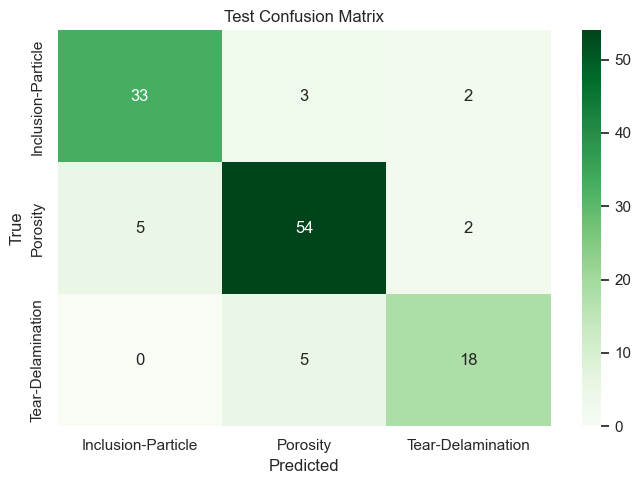

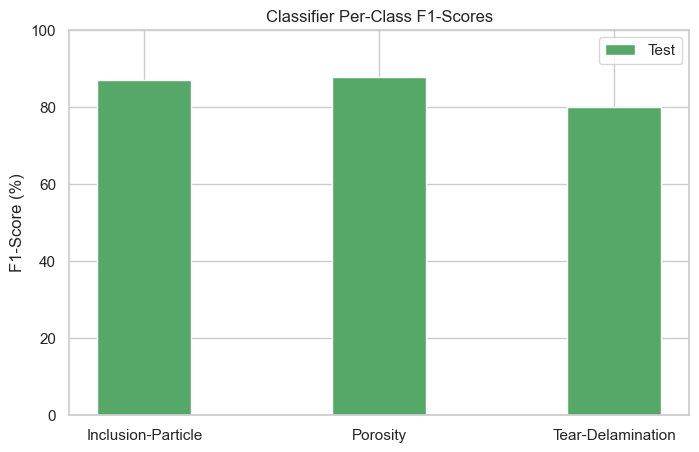

In [11]:
from torchvision import datasets
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def evaluate_classifier(data_dir, split_name):
    ds = datasets.ImageFolder(data_dir, transform=transform)
    loader = DataLoader(ds, batch_size=32, shuffle=False)
    
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = classifier(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, support = precision_recall_fscore_support(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n--- {split_name} CLASSIFIER RESULTS ---")
    print(f"Accuracy:    {acc*100:.2f}%")
    print(f"Macro F1:    {macro_f1*100:.2f}%")
    print(f"Weighted F1: {weighted_f1*100:.2f}%")
    print("\nPer-class Metrics:")
    for i, cls in enumerate(ds.classes):
        print(f"{cls:20s}: P={p[i]*100:.2f}%, R={r[i]*100:.2f}%, F1={f1[i]*100:.2f}% (Support: {support[i]})")
        
    return acc, macro_f1, weighted_f1, p, r, f1, cm, ds.classes

# Find actual test path
import glob
test_paths = glob.glob('/content/classifier_crops_eval/**/test', recursive=True)
actual_test_dir = test_paths[0] if test_paths else '/content/classifier_crops_eval/test'
actual_val_dir = os.path.join(os.path.dirname(actual_test_dir), 'valid')

if os.path.exists(actual_val_dir):
    print("Running LIVE ResNet Validation...")
    v_acc, v_mf1, v_wf1, v_p, v_r, v_f1, v_cm, cls_names = evaluate_classifier(actual_val_dir, 'VALIDATION')
else:
    print(f"Warning: Validation folder 'valid' not found at {actual_val_dir}. Skipping Validation Evaluation.")

print("\nRunning LIVE FINAL CLASSIFIER TEST EVALUATION...")
t_acc, t_mf1, t_wf1, t_p, t_r, t_f1, t_cm, cls_names = evaluate_classifier(actual_test_dir, 'BLIND TEST')

# Plotting Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(t_cm, annot=True, fmt='d', cmap='Greens', xticklabels=cls_names, yticklabels=cls_names, ax=ax)
ax.set_title('Test Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

# Plotting Per-Class F1
x = np.arange(len(cls_names))
fig, ax = plt.subplots(figsize=(8, 5))
rects2 = ax.bar(x, t_f1*100, 0.4, label='Test', color='#55A868')
ax.set_ylabel('F1-Score (%)')
ax.set_title('Classifier Per-Class F1-Scores')
ax.set_xticks(x)
ax.set_xticklabels(cls_names)
ax.legend()
plt.ylim(0, 100)
plt.show()


==================================================
# PART 7 — HISTORICAL EXPERIMENT RESULTS
==================================================

--- HISTORICAL EXPERIMENT COMPARISON ---
Best-performing evaluated detector: EXP-10 YOLO11m


/tmp/ipykernel_833/1335901382.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_hist, x='Recall', y='Run', palette='crest')


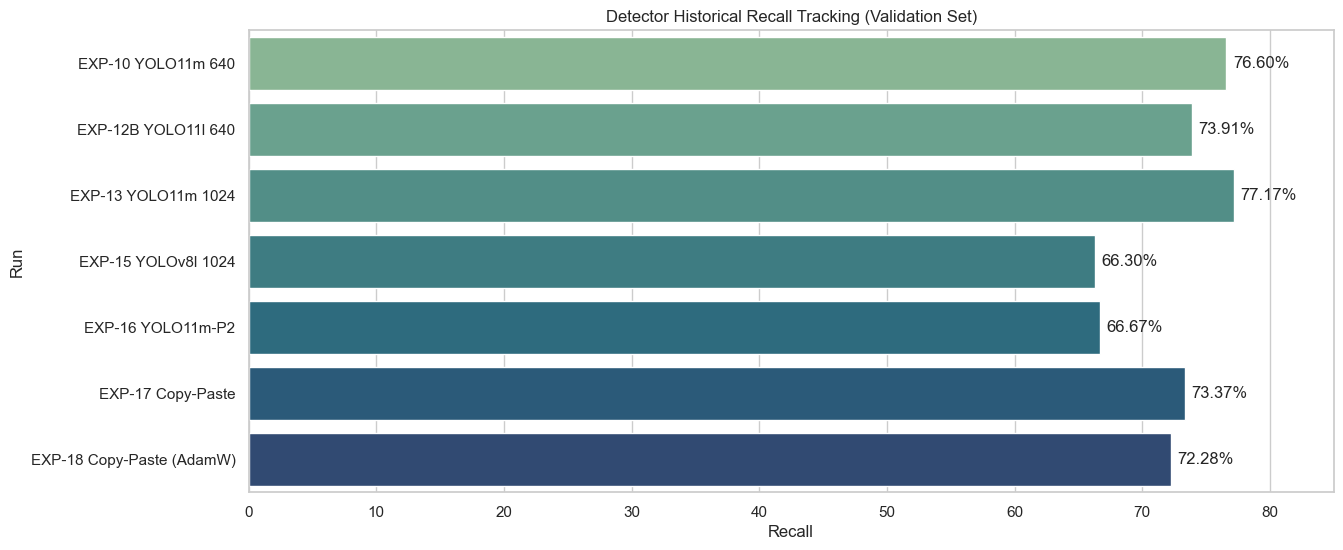

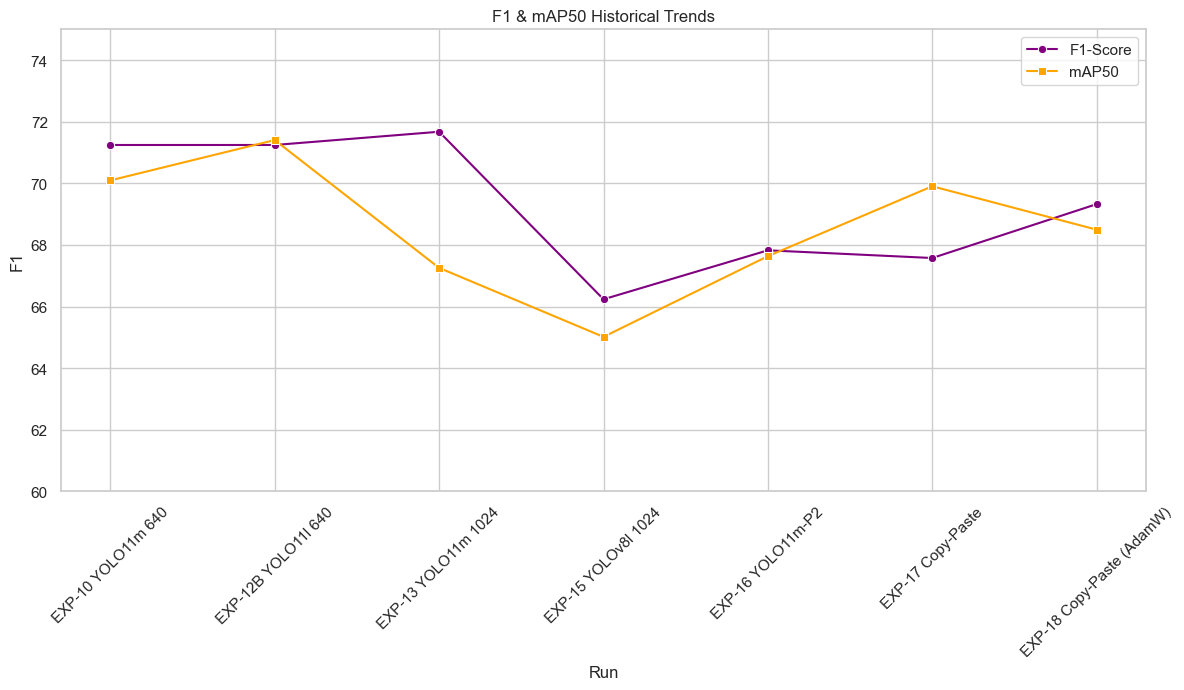

In [ ]:
# Verified from actual original reports/artifacts.
history = [
    {"Run": "EXP-10 YOLO11m 640", "Recall": 76.60, "Precision": 66.60, "F1": 71.25, "mAP50": 70.10},
    {"Run": "EXP-12B YOLO11l 640", "Recall": 73.91, "Precision": 68.77, "F1": 71.25, "mAP50": 71.41},
    {"Run": "EXP-13 YOLO11m 1024", "Recall": 77.17, "Precision": 68.19, "F1": 71.68, "mAP50": 67.26},
    {"Run": "EXP-15 YOLOv8l 1024", "Recall": 66.30, "Precision": 66.19, "F1": 66.24, "mAP50": 65.02},
    {"Run": "EXP-16 YOLO11m-P2", "Recall": 66.67, "Precision": 69.04, "F1": 67.83, "mAP50": 67.64},
    {"Run": "EXP-17 Copy-Paste", "Recall": 73.37, "Precision": 62.66, "F1": 67.58, "mAP50": 69.91},
    {"Run": "EXP-18 Copy-Paste (AdamW)", "Recall": 72.28, "Precision": 66.61, "F1": 69.33, "mAP50": 68.50}
]
df_hist = pd.DataFrame(history)

print("--- HISTORICAL EXPERIMENT COMPARISON ---")
print("Best-performing evaluated detector: EXP-10 YOLO11m")

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_hist, x='Recall', y='Run', palette='crest')
plt.title('Detector Historical Recall Tracking (Validation Set)', fontweight='bold')
for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}%", (p.get_width() + 0.5, p.get_y() + p.get_height()/2.), va='center')
plt.xlim(0, 85)
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=df_hist, x='Run', y='F1', marker='o', color='purple', label='F1-Score', ax=ax)
sns.lineplot(data=df_hist, x='Run', y='mAP50', marker='s', color='orange', label='mAP50', ax=ax)
plt.title('F1 & mAP50 Historical Trends', fontweight='bold')
plt.xticks(rotation=45)
plt.ylim(60, 75)
plt.grid(True)
plt.show()
